In [12]:
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Visualisation des données pour régions HIMAP

Colonnes disponibles : Index(['FID_bounda', 'OBJECTID_1', 'OBJECTID', 'Primary_ID', 'Secondary_',
       'Third_ID', 'Fourth_ID', 'ZLEVEL', 'Shape_Leng', 'Shape_Le_1',
       'Shape_Area', 'Nr_Region', 'FID_boun_1', 'OBJECTID_2', 'OBJECTID_3',
       'Primary__1', 'Secondary1', 'Third_ID_1', 'Fourth_I_1', 'ZLEVEL_1',
       'Shape_Le_2', 'Shape_Le_3', 'Shape_Ar_1', 'Nr_Regio_1', 'geometry'],
      dtype='object')
   FID_bounda  OBJECTID_1  OBJECTID          Primary_ID Secondary_ Third_ID  \
0           0           1         8  Eastern Hindu Kush      14.01     None   
1           1           3        10    Western Himalaya      14.03     None   
2           2           3        12    Eastern Himalaya      14.03     None   
3           3           3        11    Central Himalaya      14.03     None   
4           4           2         9           Karakoram      14.02     None   

  Fourth_ID  ZLEVEL  Shape_Leng  Shape_Le_1  ...             Primary__1  \
0      None     0.0   27.037593  

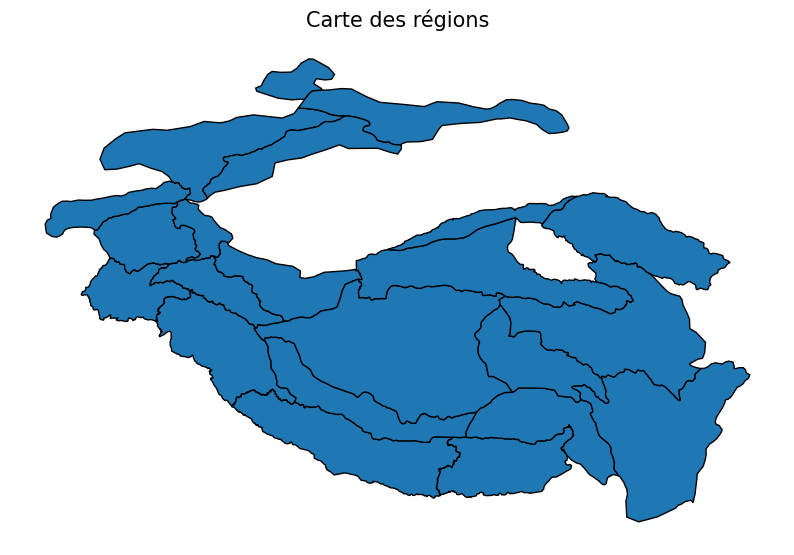

In [15]:
# 1. Chemin vers votre fichier .shp
# (S'assurer que les autres fichiers .dbf, .prj, etc. sont dans le même dossier)
chemin_fichier = "/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"

# 2. Chargement des données
regions = gpd.read_file(chemin_fichier)

# 3. Aperçu des données (pour vérifier le nom des colonnes)
print("Colonnes disponibles :", regions.columns)
print(regions.head())

# 4. Création de la carte
# 'column' permet de colorer selon une donnée (ex: 'Primary_ID')
regions.plot(column=None,
            legend=True, 
            figsize=(10, 10), 
            edgecolor='black') # Dessine les contours

# 5. fignolage de l'affichage
plt.title("Carte des régions", fontsize=15)
plt.axis('off') # Cache les coordonnées X/Y pour un rendu plus propre

# 6. Affichage
plt.show()

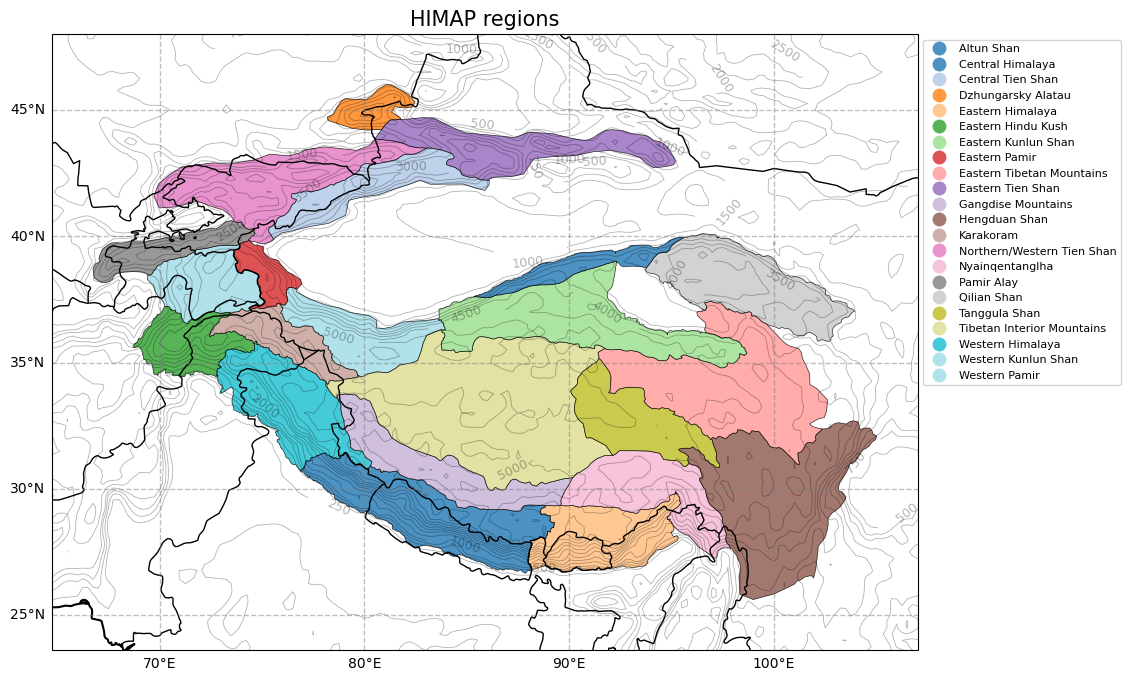

In [16]:
# Configuration de la projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 8))

# Chargement des données
chemin_fichier = "/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"
regions = gpd.read_file(chemin_fichier)

# S'assurer que le shapefile est dans le même système de coordonnées que l'axe
# Si le SHP n'est pas en WGS84 (EPSG:4326), on le convertit
if regions.crs != "EPSG:4326":
    regions = regions.to_crs("EPSG:4326")

# Affichage des données sur l'axe existant (ax=ax)
regions.plot(ax=ax, 
             column='Primary_ID',      
             categorical=True,   # Précise que ce sont des catégories
             cmap='tab20',       # Palette de couleurs
             edgecolor='black', 
             linewidth=0.5,
             alpha=0.8, 
             legend=True,
             legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1), 'fontsize': 8})

# Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

# Ajuster la vue sur l'étendue des données 
bounds = regions.total_bounds  # [minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-2, bounds[2]+2, bounds[1]-2, bounds[3]+2], crs=ccrs.PlateCarree())

plt.title("HIMAP regions", fontsize=15)

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()